In [236]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df_graphing = pd.read_csv("data/emergency_triage_clean.csv", sep=',', decimal=".")
df_graphing.head(4)


,Group,SEX_Female,SEX_Male,Age,AGE_19,AGE_39,AGE_59,AGE_79,AGE_80+,Arrival mode,...,HR,RR,BT,SpO2,Nurse_KTAS,Disposition,Expert_KTAS,KTAS_match,Length of stay_min,KTAS duration_min
0,2,0,1,71,0,0,0,1,0,3,...,84.0,18.0,36.6,100.0,2,1,4,False,86,5.00
1,1,1,0,56,0,0,1,0,0,3,...,60.0,20.0,36.5,NaN,4,1,5,False,64,3.95
2,2,1,0,68,0,0,0,1,0,2,...,102.0,20.0,36.6,98.0,4,2,5,False,862,1.00
3,1,0,1,71,0,0,0,1,0,1,...,88.0,20.0,36.5,NaN,4,1,5,False,108,9.83


In [237]:
plt.figure(figsize=(15, 9))

<Figure size 1500x900 with 0 Axes>

<Figure size 1500x900 with 0 Axes>

In [238]:
df_graphing['Expert_KTAS'].value_counts().sort_index()

Expert_KTAS
1     26
2    220
3    487
4    459
5     75
Name: count, dtype: int64

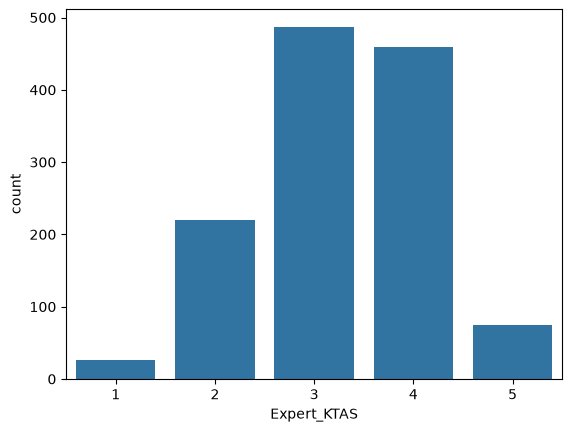

In [239]:
sns.countplot(data=df_graphing, x = 'Expert_KTAS')
plt.show()

1. Which KTAS level contains the most patients?
    Level 3 is the most common.
2. Which KTAS level contains the fewest patients?
    Level 1 is the least common.
3. Is the distribution balanced across the five levels?
    The distribution is concentrated near levels 3 and 4 and looks a little like a bell curve. 

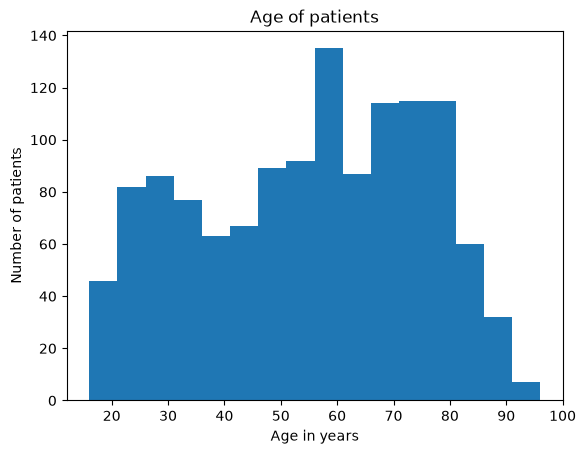

In [240]:
plt.hist(df_graphing['Age'], bins= 16)
plt.title("Age of patients")
plt.xlabel('Age in years')
plt.ylabel('Number of patients')
plt.show()

1. Which age range contains many patients?
    There are many patients in between 50 and 80 years old.
2. Is the age distribution symmetric or skewed?
    It is slight skewed to the older side, however there are not many very old patients.
3. Are there very young or very old patients?
    The youngest patients are 16 years old and the oldest is 96 years old. 

Text(0, 0.5, 'Number of patients in an age group')

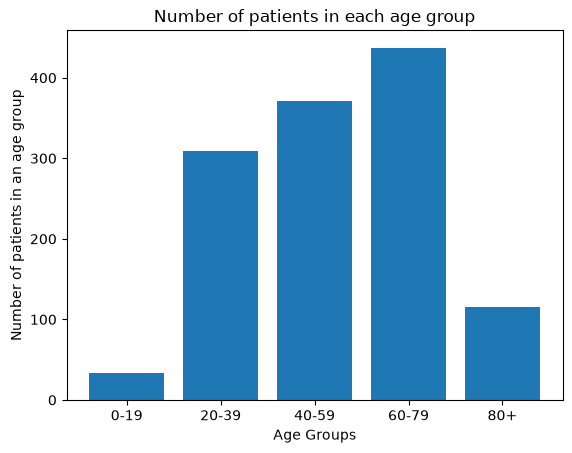

In [241]:
values1 = [df_graphing['AGE_19'].sum(),df_graphing['AGE_39'].sum(),df_graphing['AGE_59'].sum(),df_graphing['AGE_79'].sum(),df_graphing['AGE_80+'].sum()]
plt.bar(['0-19','20-39','40-59','60-79','80+'],values1)
plt.title('Number of patients in each age group')
plt.xlabel('Age Groups')
plt.ylabel('Number of patients in an age group')


The most common group is 60-79, while the least common group is 0 - 19. There are about 470 in 60-79 and 30 in 0-19

[Text(0, 0, '606'), Text(0, 0, '661')]

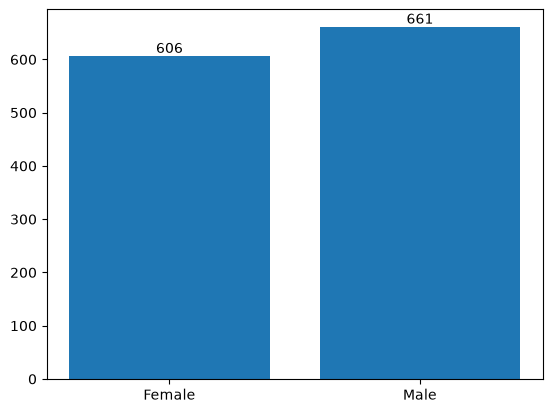

In [242]:
values = [df_graphing['SEX_Female'].sum(),df_graphing['SEX_Male'].sum()]
Sex = plt.bar(['Female','Male'],values)
plt.bar_label(Sex)

1. Which category contains more patients?
    The male category has 661 patients, while the female catergory has 606 patients.
2. Is the difference large or small?
    The difference is small compared to both groups. 

<Axes: xlabel='Expert_KTAS', ylabel='Age'>

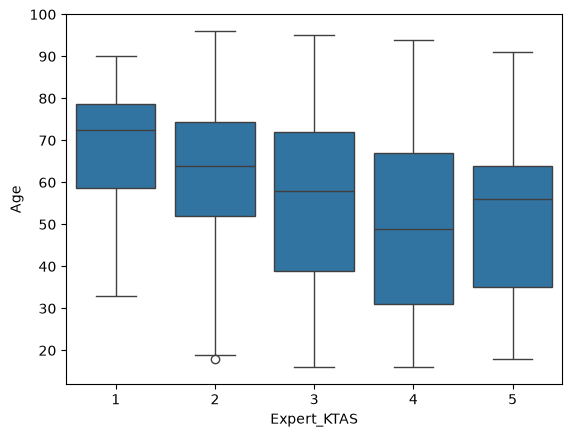

In [243]:
sns.boxplot(data = df_graphing, x ='Expert_KTAS', y = 'Age')

1. Which KTAS level has the highest median age?
    KTAS Level 1 has the highest median age.
2. Which level has the widest age distribution?
    KTAS level 3 has the widest age range
3. Are outliers visible?
    There is an outlier on Expert_KTAS level 2 on the lower end.

<Axes: xlabel='Expert_KTAS', ylabel='SpO2'>

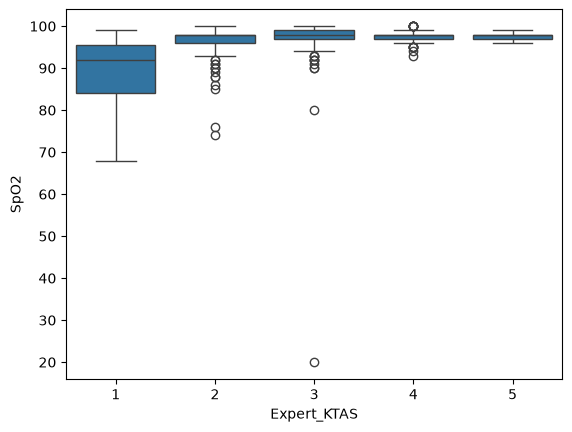

In [244]:
df_NoNAN = df_graphing.dropna(subset=['SpO2'])
sns.boxplot(data=df_NoNAN, x='Expert_KTAS', y='SpO2')

1. Which KTAS level has the lowest median SpO₂?
    Expert KTAS level 1 has the lowest median SpO2. 
2. Which levels contain low SpO₂ outliers?
    Levels 2,3, and 4 have low SpO2 outliers.
3. Are the distributions clearly separated?
    A lot of overlap in KTAS 2- 5. 

In [245]:
age_cols = ['AGE_19','AGE_39','AGE_59','AGE_79','AGE_80+']
for col in age_cols:
    print(f"\n{col}")
    print(pd.crosstab(df_graphing[col], df_graphing['Expert_KTAS']))


AGE_19
Expert_KTAS   1    2    3    4   5
AGE_19                            
0            26  218  476  441  72
1             0    2   11   18   3

AGE_39
Expert_KTAS   1    2    3    4   5
AGE_39                            
0            25  196  373  308  56
1             1   24  114  151  19

AGE_59
Expert_KTAS   1    2    3    4   5
AGE_59                            
0            20  147  360  322  47
1             6   73  127  137  28

AGE_79
Expert_KTAS   1    2    3    4   5
AGE_79                            
0            12  127  305  333  53
1            14   93  182  126  22

AGE_80+
Expert_KTAS   1    2    3    4   5
AGE_80+                           
0            21  192  434  432  72
1             5   28   53   27   3


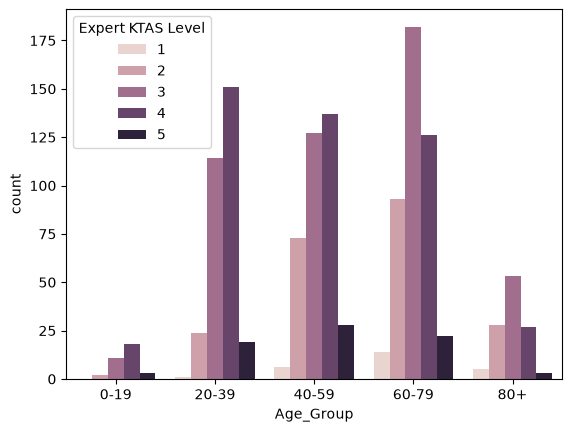

In [246]:
age_cols = ['AGE_19', 'AGE_39', 'AGE_59', 'AGE_79', 'AGE_80+']

mapping = {
    'AGE_19': '0-19',
    'AGE_39': '20-39',
    'AGE_59': '40-59',
    'AGE_79': '60-79',
    'AGE_80+': '80+'
}

df_graphing['Age_Group'] = (
    df_graphing[age_cols]
    .idxmax(axis=1)
    .map(mapping)
)

cross = pd.crosstab(
    df_graphing['Age_Group'],
    df_graphing['Expert_KTAS']
)

sns.countplot(
    data=df_graphing,
    x='Age_Group',
    hue='Expert_KTAS', 
    order=['0-19', '20-39', '40-59', '60-79', '80+']

)
plt.legend(title='Expert KTAS Level')

1. Does the KTAS distribution differ across age groups?
    Slighty, although 3 or 4 is the most common level across all 5 age groups.
2. Which age group has more high-acuity patients?
    Age group 60-79, had the most high acuity patients wth the most 1,2,and 3 patients. 
3. Are comparisons affected by differences in the total number of patients per age groups?
    If it is by percentage, not as much, but if it is about the pure number of patints in a certain KTAS level, than the total number of patients per age group does matter. 

<Axes: xlabel='HR', ylabel='RR'>

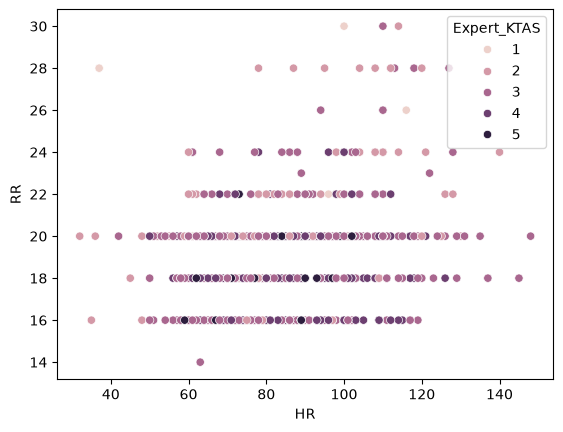

In [247]:
df_graphing.dropna(subset=['HR'])
df_graphing.dropna(subset=['RR'])
sns.scatterplot(data= df_graphing, x = 'HR', y= 'RR', hue = 'Expert_KTAS')


1. Do heart rate and respiratory rate appear to increase together?
    Not exactly, there was a lot of plots that have a high HR, but low RR.
2. Are the points widely scattered?
    There are a lot of points from 22 - 16, but its widely scattered above and below that range.
3. Do KTAS levels form separate groups?
    There are mnay differnt type of KTAS levels in the "normal" range, but the more abnormal the HR and/or RR, the more likely it is to be KTAS level 1-3.

<Axes: xlabel='Age', ylabel='Length of stay_min'>

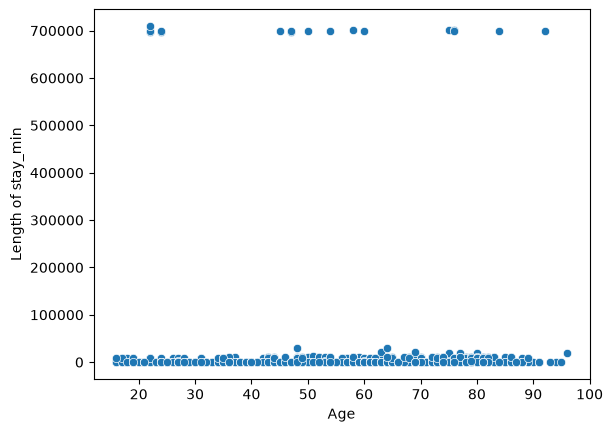

In [248]:
sns.scatterplot(data= df_graphing, x = 'Age', y= 'Length of stay_min')


1. Does length of stay appear to increase with age?
    Not exactly, there are only a few patients with very long stays and they are spread across age. Other than that, age doesnt seem to have an effect as there isn't any linear movement. 
2. Are there patients with unusually long stays?
    A few have around 700,000 minute stays. 
3. Is the relationship strong or weak?
    Weak, not that much of a pattern. 

<Axes: xlabel='Expert_KTAS', ylabel='KTAS duration_min'>

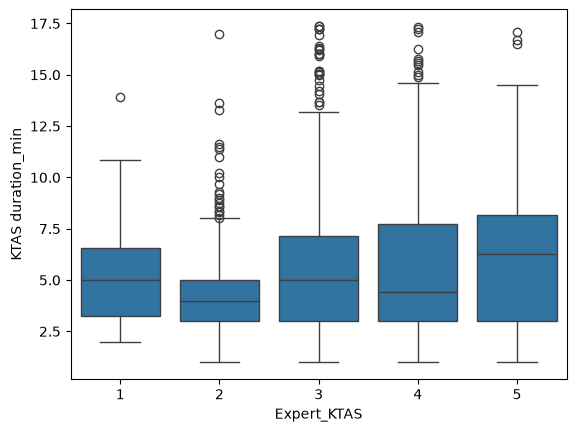

In [249]:
sns.boxplot(data= df_graphing, x = 'Expert_KTAS',y= 'KTAS duration_min')

1. Which KTAS level has the highest median duration? 
    KTAS level 5, has the highest median duration.
2. Which level has the largest variation?
    Level 4 has the largest variation.
3. Are there extreme outliers?
    There are extreme outliers in all KTAS levels, with all of them being high outliers.

Text(50.83333333333333, 0.5, 'Nurse KTAS')

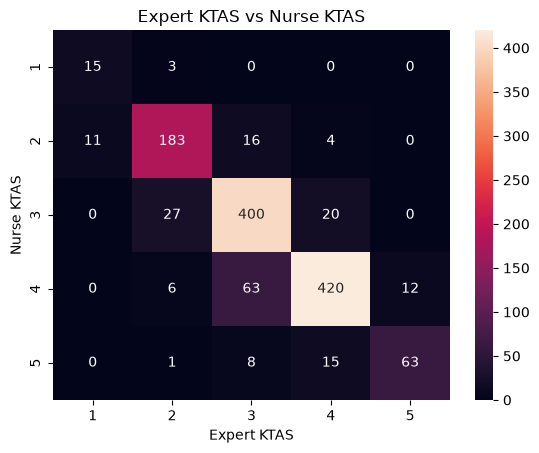

In [250]:
cross = pd.crosstab( df_graphing['Nurse_KTAS'],df_graphing['Expert_KTAS'])
sns.heatmap(cross,annot=True, fmt="d")
plt.title('Expert KTAS vs Nurse KTAS')
plt.xlabel('Expert KTAS')
plt.ylabel('Nurse KTAS')

1. What do the diagonal cells represent?
    They represent when both the expert, and the nurse got the same KTAS diagnosis
2. Which KTAS level has the most matching cases?
    KTAS level 4, and KTAS level 3 was close with 20 less matches.
3. Between which levels do disagreements occur frequently?
    Between levels 3,4 and 2 respectfully. 

Text(0, 0.5, 'Number of matches or mismatches')

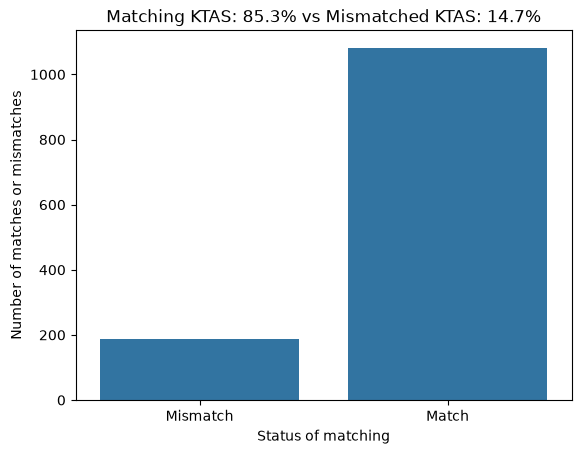

In [251]:
match = (df_graphing['KTAS_match'].mean()*100)

df_graphing['KTAS_match'] = df_graphing['KTAS_match'].map({True: 'Match', False: 'Mismatch'})
sns.countplot(data=df_graphing,x='KTAS_match')

Title = f"Matching KTAS: {match:.1f}% vs Mismatched KTAS: {(100-match):.1f}%"
plt.title(Title)
plt.xlabel('Status of matching')
plt.ylabel('Number of matches or mismatches')

<Axes: xlabel='Group', ylabel='count'>

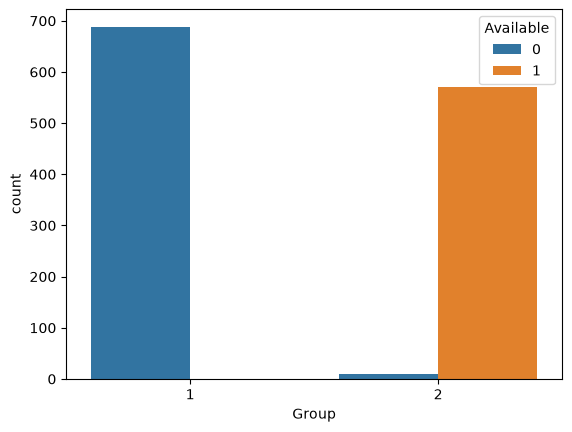

In [254]:
df_graphing['Available'] = np.where(df_graphing['SpO2'].isnull(), '0', '1')
sns.countplot(data=df_graphing,x='Group', hue='Available')

1. Which group contains more missing SpO₂ values?   
    Group 1.
2. Are missing records evenly distributed?
    No, there are almost 700 missing SpO2 values in group 1, while there are only 9 in group 2.
3. Why could this pattern affect later analysis?
    Missing values is very skewed towards group 1, while filled values are very skewed toward group 2. 

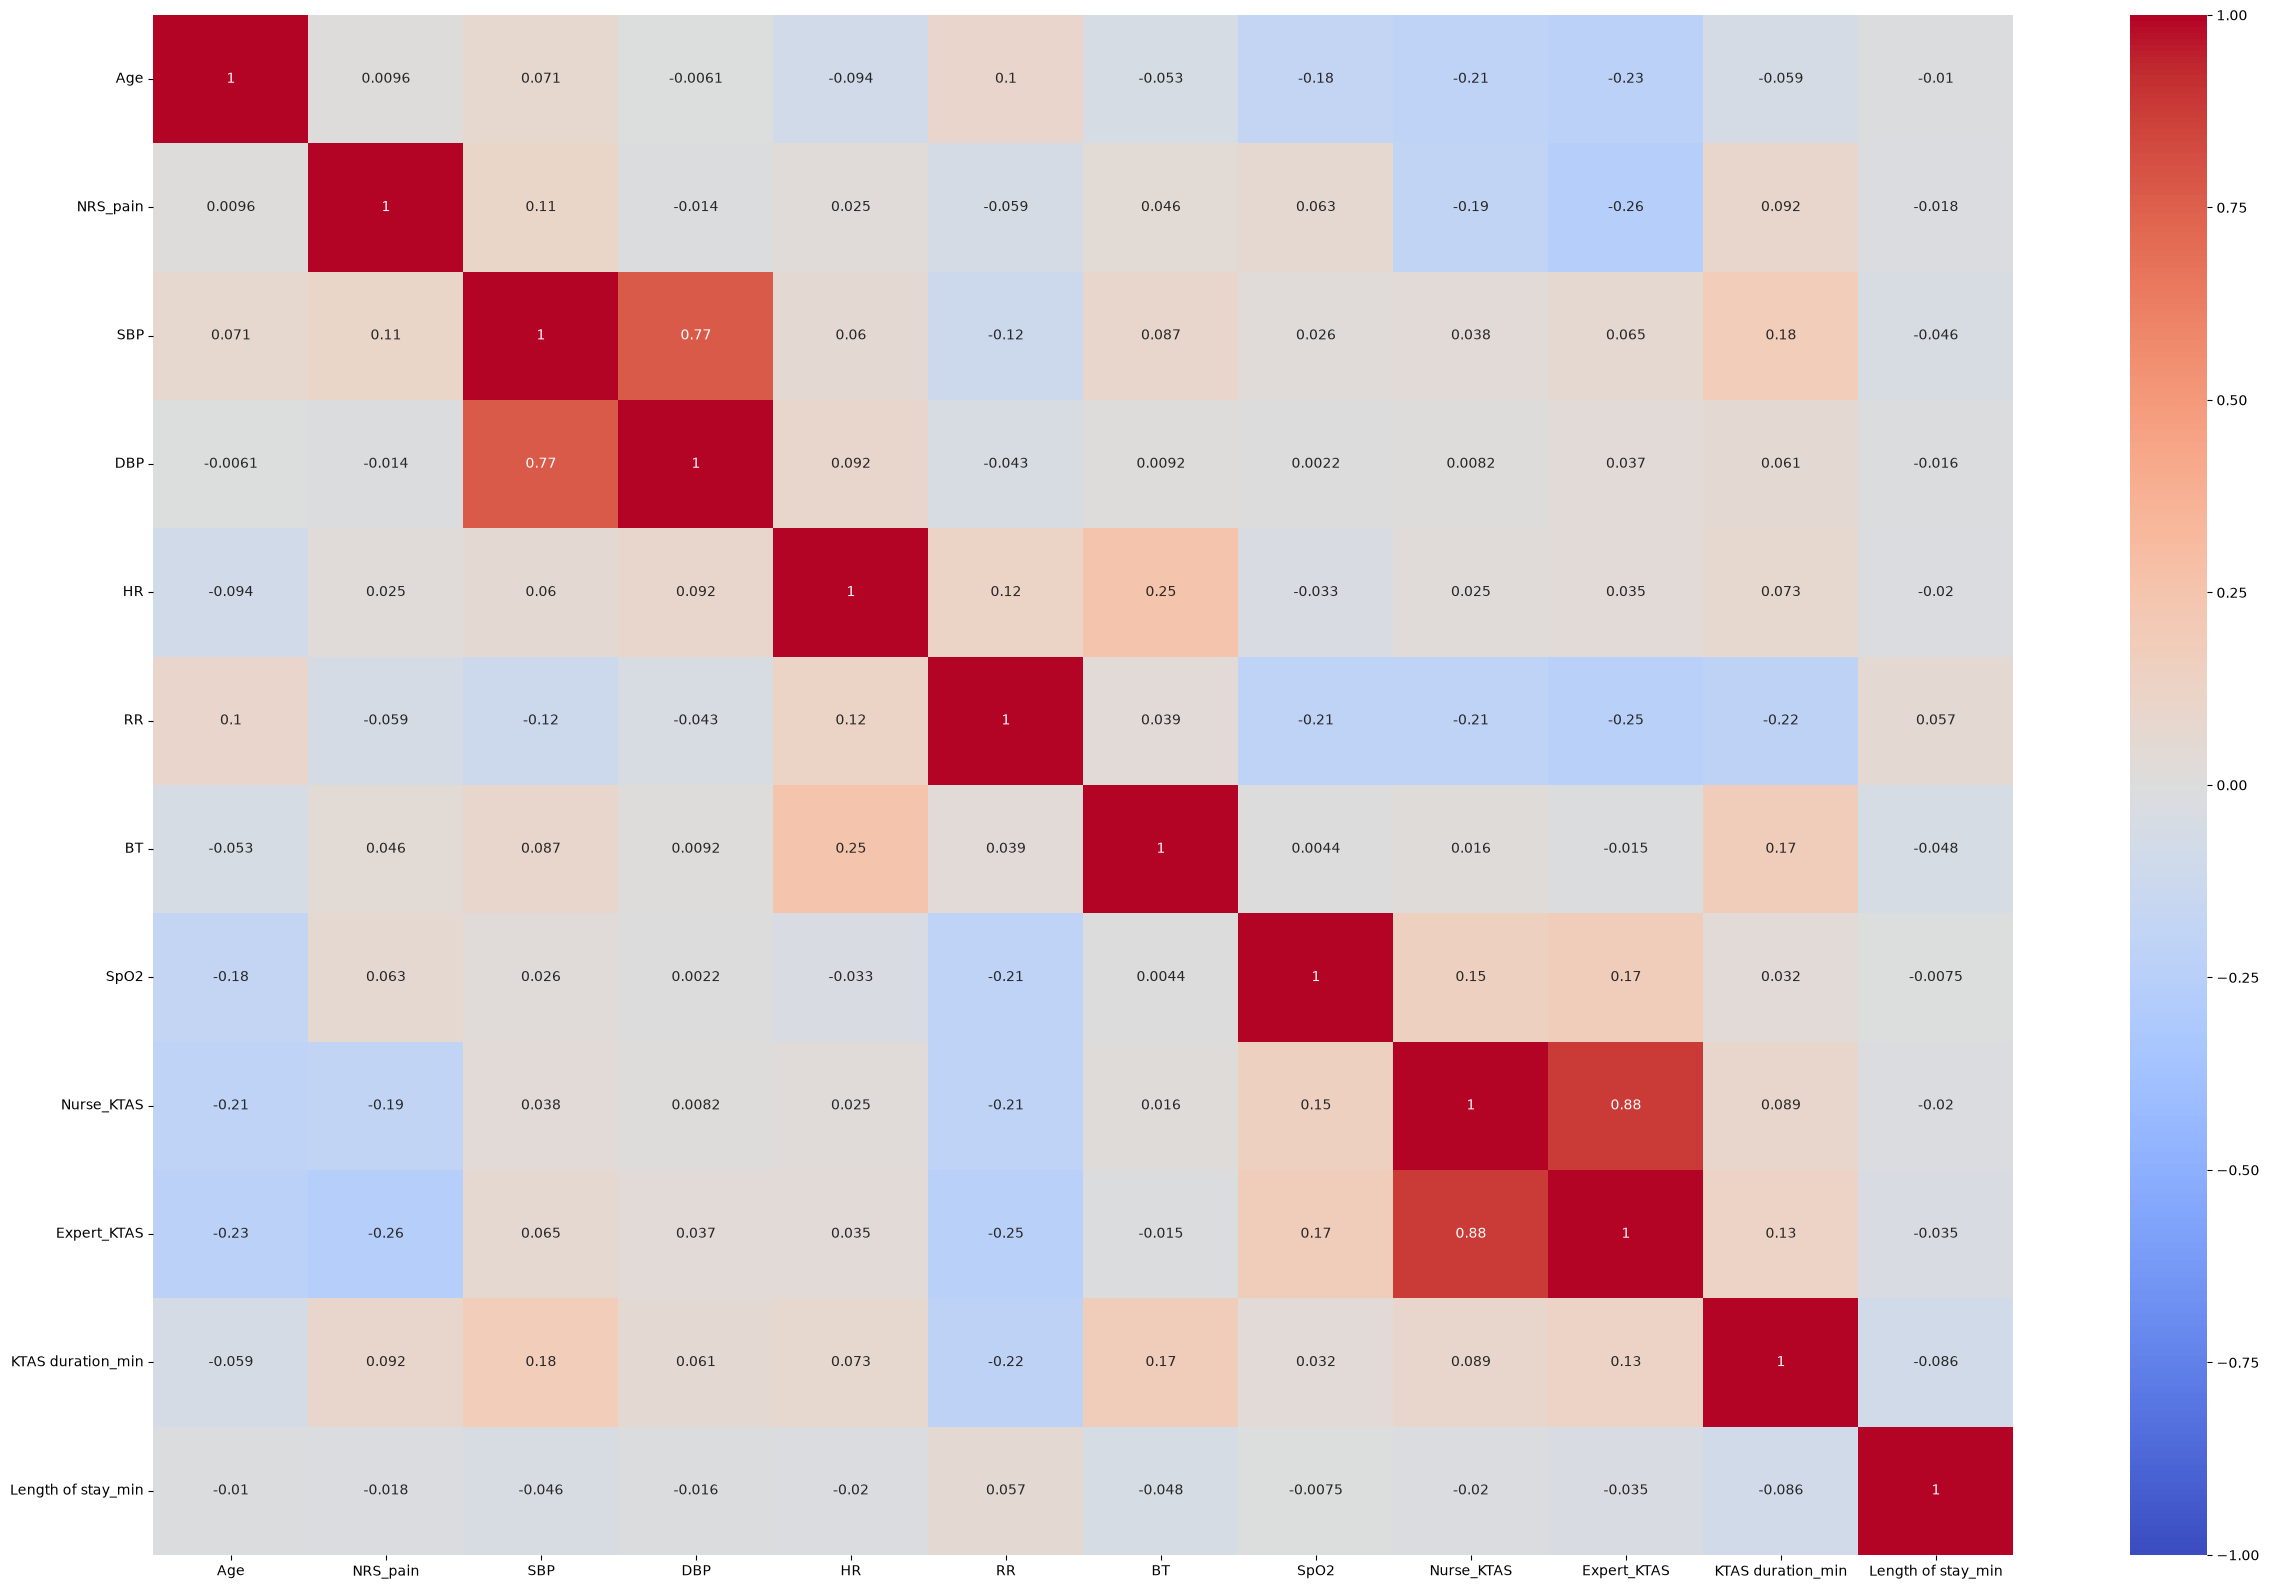

In [256]:
plt.figure(figsize=(30, 20))
cols = [
    'Age',
    'NRS_pain',
    'SBP',
    'DBP',
    'HR',
    'RR',
    'BT',
    'SpO2',
    'Nurse_KTAS',
    'Expert_KTAS',
    'KTAS duration_min',
    'Length of stay_min'
]

corr = df_graphing[cols].corr()

heatmap = sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()


1. Which two variables show the strongest negative correlation?
    Expert KTAS and NRS_pain.
2. Which two variables show the strongest positive correlation?
    Nurse_KTAS and Expert_KTAS
3. Are most relationships strong or weak?
    Most relationsips are weak.
4. Why does correlation not prove causation?
    There can be correlation between the number of movies watched and the number of people who like blue, but it might not be cuasation becuase it does not effect eachother. 

Text(0, 0.5, 'Expert KTAS')

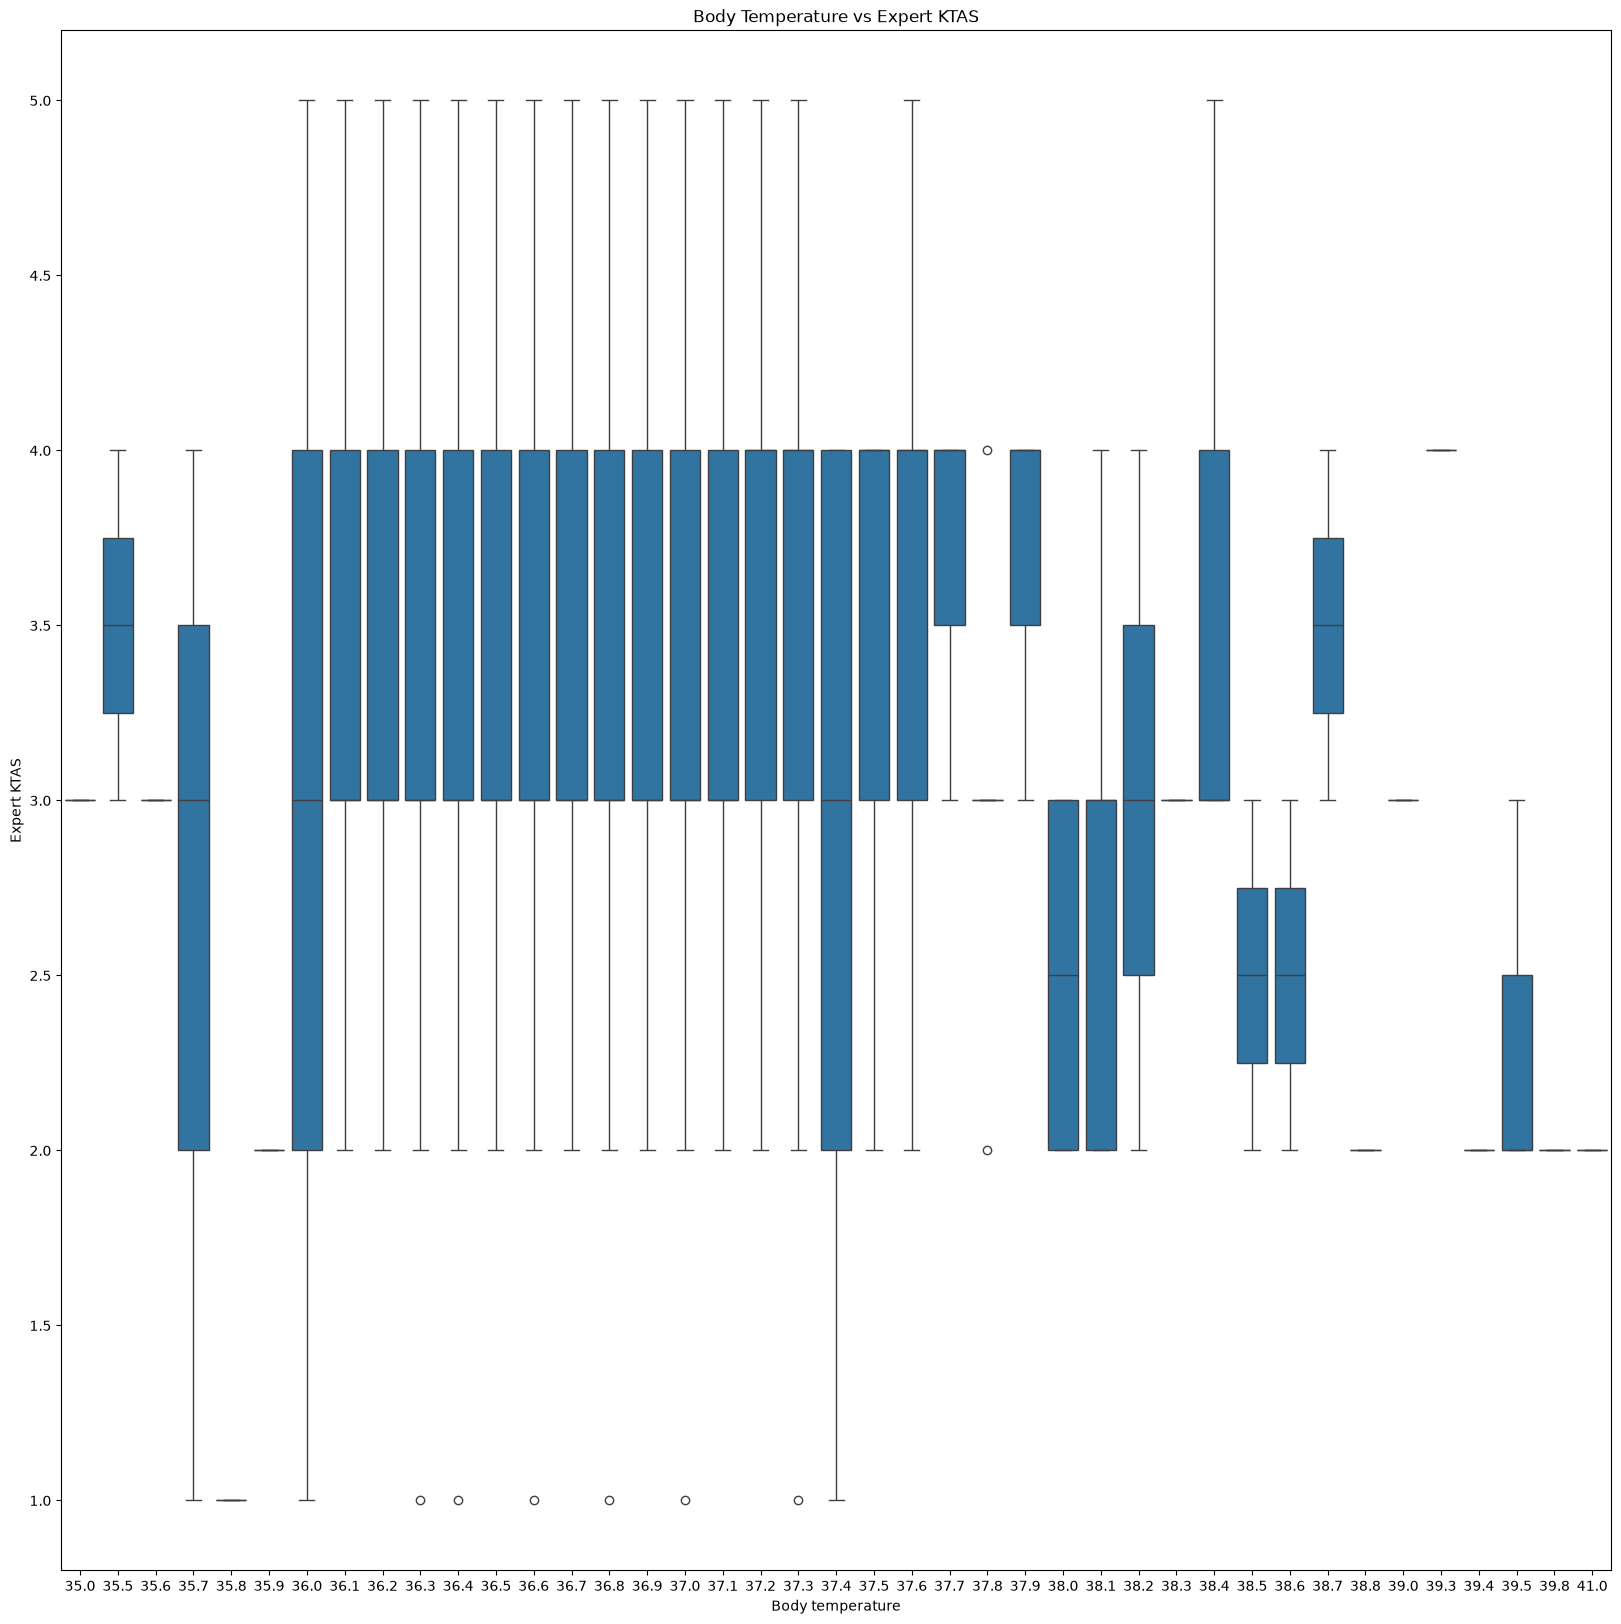

In [270]:
plt.figure(figsize=(20, 20))
sns.boxplot(data=df_graphing,x='BT',y ='Expert_KTAS')
plt.title('Body Temperature vs Expert KTAS')
plt.xlabel('Body temperature')
plt.ylabel('Expert KTAS')

This boxplot compares the expert KTAS with body temperature. The temperature with the biggest KTAS range was 36.0, and there were KTAS 1 patients on the lower half of the temperatures. 

Explain why you selected that graph type.
    I wanted to show the median KTAS of each body temperature to see if it changes as the BT increases.

<Axes: xlabel='HR', ylabel='RR'>

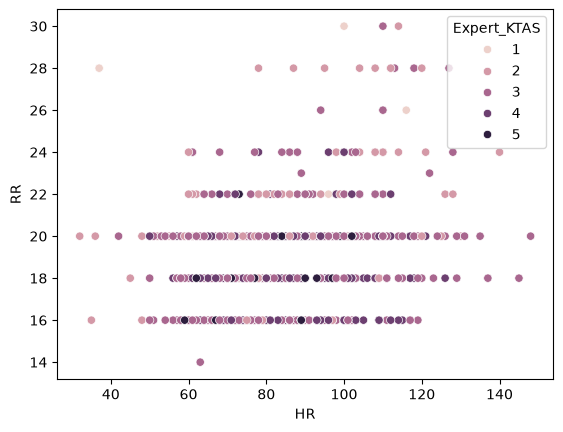

In [273]:
df_graphing.dropna(subset=['HR'])
df_graphing.dropna(subset=['RR'])
sns.scatterplot(data= df_graphing, x = 'HR', y= 'RR', hue = 'Expert_KTAS')

C:\Users\1\AppData\Local\Temp\ipykernel_12740\1975948670.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


<Axes: title={'center': 'Heart rate and Respiration rate vs KTAS'}, xlabel='Heart rate', ylabel='Respiration rate'>

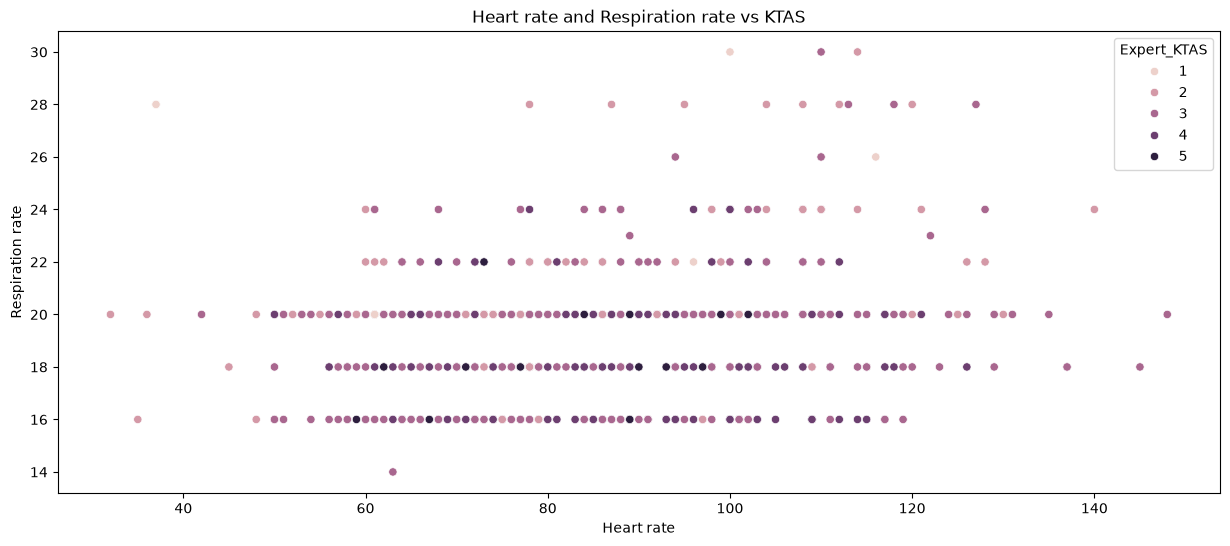

In [276]:
plt.figure(figsize= (15,6))
plt.title("Heart rate and Respiration rate vs KTAS")
plt.xlabel("Heart rate")
plt.ylabel("Respiration rate")
df_graphing.dropna(subset=['HR'])
df_graphing.dropna(subset=['RR'])
plt.legend(loc='best')
sns.scatterplot(data= df_graphing, x = 'HR', y= 'RR', hue = 'Expert_KTAS')

I updated the X and Y labels so it's easier to understand and included a title. I also increased the width of the graph as there was some overlap in the original graph. 

1. Which Expert KTAS level contains the most patients?
    KTAS level 3 has the most patients.
2. Which age group contains the most patients?
    The 60-79 age group has the most patients.
3. How does patient age differ across KTAS levels?
    The median age increase as KTAS decreases, except for level 5 which has a high median age.
4. Does SpO₂ appear different across KTAS levels?
    While it is similar for KTAS 3,4 and 5, for KTAS 1 and 2, there is more range and lower values of SpO2.
5. Is there a visible relationship between heart rate and respiratory rate?
    Not a strong relationship, as there are many values of high HR and low RR and vice versa, along with medium HR and medium RR
6. How often do nurse and expert KTAS results match?
    They match 85.3% of the time. 
7. Which KTAS levels show frequent disagreement?
    KTAS levels 3,4 and 2.
8. Are missing SpO₂ records evenly distributed across `Group`?
    There are many missing SpO2 records in Group 1, as they are 100% missing, which is very bad.
9. Which numeric variables show noticeable correlations?
    DBP and SBP & Nurse_KTAS and Expert_KTAS
10. Which visualization was the most useful?
    I found the heat maps very useful because it's hard to compare 2 sets of data when there are many reports.
11. Which visualization was the most difficult to create?
    The number of patients in each age group. 
12. What additional data would help you interpret the results?
    Maybe a heat map of every variable.